# Internet AS-level network builder

This notebook shows how to use `get_network_internet_as`, the builder that generates a
`Network` resembling the Internet at the level of Autonomous Systems (ASes), and how
to draw it.

The topology comes from `networkx.random_internet_as_graph`, which implements the
model of Elmokashfi, Kvalbein and Dovrolis (*On the Scalability of BGP: The Role of
Topology Growth*, IEEE JSAC 2010). Every AS has a type and every link a commercial
relationship:

| AS type | Role |
|---|---|
| `T` Tier-1 | global backbone, peering with the other Tier-1 ASes |
| `M` mid-level | regional transit provider |
| `CP` content provider | large content networks, with many peering links |
| `C` customer | stub networks at the edge |

Links are `transit` (provider to customer) or `peer` (traffic exchanged as equals).

The builder converts the AS graph into a `Network`:

- every AS becomes a router `as_<id>`, with the attribute `as_type`;
- every AS link becomes a bidirectional link that keeps `relationship` and `customer`;
- hosts (`host_<id>_<h>`) are attached to the customer and content-provider ASes,
  where services run;
- the model has no geography and no capacities, so every link gets the bandwidth and
  length of its **class**, the lowest tier among its endpoints (`T`, `M`, `CP`, `C`,
  or `host` for host links).

## Setup

In [1]:
import json
import os
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.lines import Line2D

from eclypse.builders.network import get_network_internet_as
from eclypse.network import (
    NetworkApplication,
    PacketGenerationEvent,
    RoutingEvent,
    RoutingMetric,
)
from eclypse.placement.strategies import StaticStrategy
from eclypse.simulation import Simulation, SimulationConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Chart style: light surface, recessive axes and grid
SURFACE, TEXT, TEXT_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_MUTED,
    "axes.titlecolor": TEXT,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "legend.frameon": False,
    "legend.labelcolor": TEXT,
    "font.size": 10,
})

# AS types: one blue ramp (dark = core) plus a distinct marker per type
AS_STYLE = {
    "T": {"label": "Tier-1 (T)", "color": "#0d366b", "marker": "H"},
    "M": {"label": "Mid-level (M)", "color": "#1c5cab", "marker": "s"},
    "CP": {"label": "Content provider (CP)", "color": "#3987e5", "marker": "D"},
    "C": {"label": "Customer (C)", "color": "#86b6ef", "marker": "o"},
}
HOST_STYLE = {"label": "Host", "color": "#a3a29d", "marker": "."}
LINK_CLASSES = ["T", "M", "CP", "C", "host"]


def plain_graph(network, nodes):
    # Undirected networkx copy of part of a Network, used for layouts and drawing
    nodes = set(nodes)
    graph = nx.Graph()
    graph.add_nodes_from((n, dict(network.nodes[n])) for n in nodes)
    graph.add_edges_from(
        (u, v, dict(d)) for u, v, d in network.edges(data=True) if u in nodes and v in nodes
    )
    return graph

## 1. Build the network

`n` is the number of ASes (the networkx documentation validates the model for 1000 to
10000). Bandwidths and lengths can be overridden per link class; here we keep the
defaults.

In [2]:
net = get_network_internet_as(
    1000,
    hosts_per_customer=1,
    hosts_per_content_provider=2,
    max_queue_size=100,
    seed=SEED,
)

print(f"{net.number_of_nodes()} nodes ({len(net.routers)} AS routers, {len(net.hosts)} hosts), "
      f"{net.number_of_edges() // 2} bidirectional links")
print("Connected:", nx.is_strongly_connected(net))

ases = pd.DataFrame(
    [
        {"as_type": net.nodes[r]["as_type"],
         "as_links": sum(net.edges[r, v]["link_class"] != "host" for v in net.successors(r))}
        for r in net.routers
    ]
)
print("\nASes per type")
print(ases.groupby("as_type")["as_links"].agg(ases="count", mean_degree="mean", max_degree="max")
      .reindex(["T", "M", "CP", "C"]).round(1).to_string())

links = pd.DataFrame(
    [{"class": d["link_class"], "relationship": d.get("relationship", "-"),
      "bandwidth_mbps": d["bandwidth_mbps"], "length_km": d["length_km"]}
     for u, v, d in net.edges(data=True) if u < v]
)
print("\nLinks per class")
print(links.groupby("class")
      .agg(links=("length_km", "size"), bandwidth_mbps=("bandwidth_mbps", "first"),
           length_km=("length_km", "first"),
           transit=("relationship", lambda r: (r == "transit").sum()),
           peer=("relationship", lambda r: (r == "peer").sum()))
      .reindex(LINK_CLASSES).to_string())

1895 nodes (1000 AS routers, 895 hosts), 2411 bidirectional links
Connected: True

ASes per type
         ases  mean_degree  max_degree
as_type                               
T           5         60.2          86
M         150         11.7          89
CP         50          2.9           5
C         795          1.0           2

Links per class
       links  bandwidth_mbps  length_km  transit  peer
class                                                 
T         10        100000.0     2000.0        0    10
M        535         10000.0      500.0      340   195
CP       140         10000.0      200.0      119    21
C        831          1000.0       50.0      831     0
host     895           100.0        1.0        0     0


## 2. Draw the network

Left: the AS graph (routers only), with a force-directed layout. Node size grows with
the number of AS links, so the hubs stand out at the center. Right: a single mid-level
AS with its neighbours and the hosts of its customers, which shows the result of the
conversion.

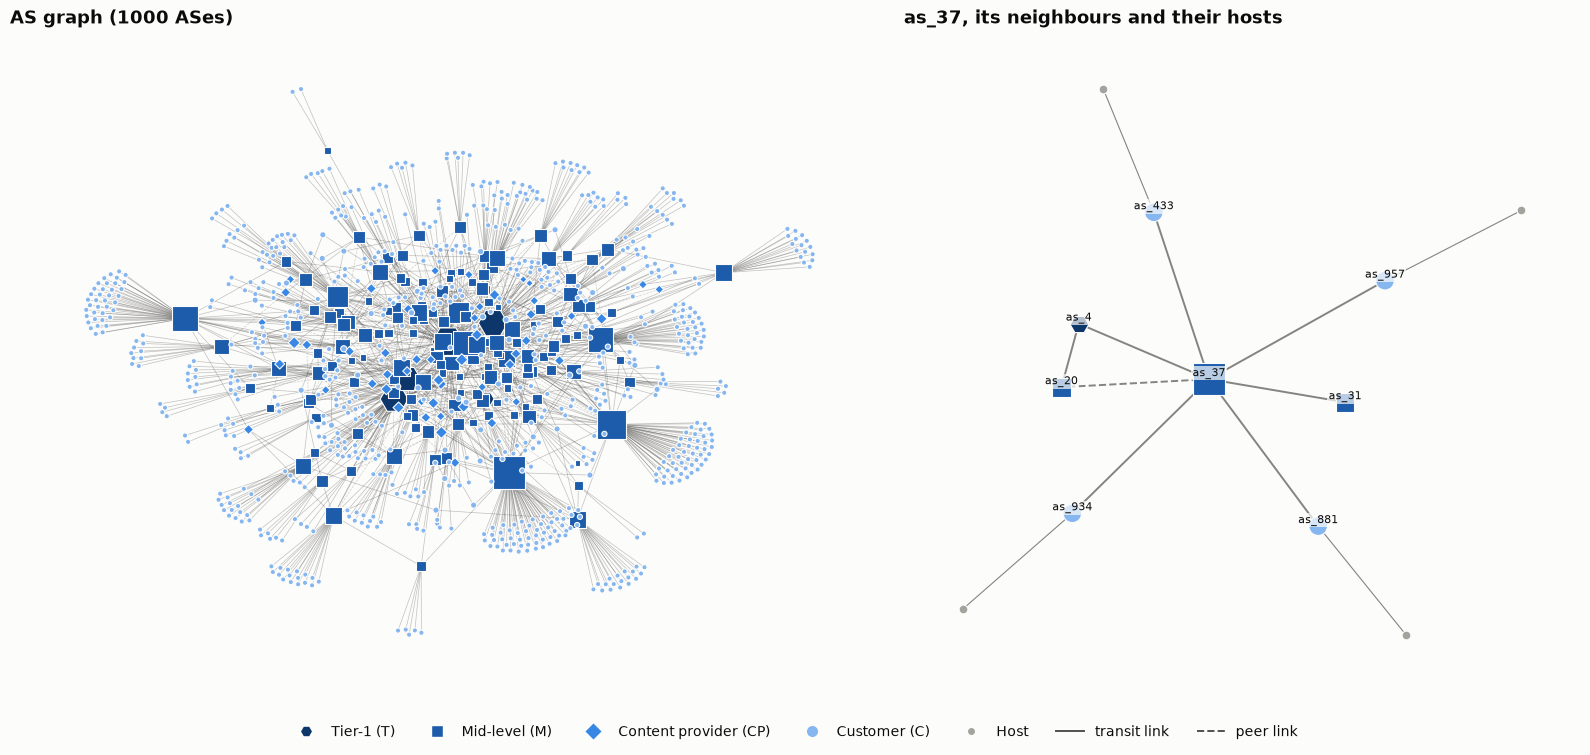

In [3]:
as_graph = plain_graph(net, net.routers)
degree = dict(as_graph.degree())
layout = nx.spring_layout(as_graph, k=0.08, iterations=200, seed=SEED)


def draw_nodes(ax, graph, pos, nodes, size):
    for as_type, style in AS_STYLE.items():
        group = [n for n in nodes if graph.nodes[n].get("as_type") == as_type and n in net.routers]
        nx.draw_networkx_nodes(graph, pos, nodelist=group, ax=ax, node_color=style["color"],
                               node_shape=style["marker"], node_size=[size(n) for n in group],
                               edgecolors=SURFACE, linewidths=0.8)


fig, (ax_all, ax_ego) = plt.subplots(1, 2, figsize=(16, 7.5), gridspec_kw={"width_ratios": [1.3, 1]})

# Whole AS graph: peer links lighter than transit links
for relationship, alpha in (("peer", 0.25), ("transit", 0.35)):
    edges = [(u, v) for u, v, d in as_graph.edges(data=True) if d["relationship"] == relationship]
    nx.draw_networkx_edges(as_graph, layout, edgelist=edges, ax=ax_all, width=0.5,
                           edge_color=TEXT_MUTED, alpha=alpha,
                           style="dashed" if relationship == "peer" else "solid")
draw_nodes(ax_all, as_graph, layout, as_graph.nodes(), lambda n: 8 + 6 * degree[n])
ax_all.set_title(f"AS graph ({as_graph.number_of_nodes()} ASes)", loc="left")
ax_all.axis("off")

# Ego network of a mid-level AS with a handful of customers
def customers_with_hosts(router):
    return [v for v in as_graph.neighbors(router)
            if as_graph.nodes[v]["as_type"] == "C" and any(h in net.hosts for h in net.successors(v))]


mid = [r for r in net.routers if net.nodes[r]["as_type"] == "M"]
ego_center = min(mid, key=lambda r: (abs(len(customers_with_hosts(r)) - 4), degree[r]))
neighbours = set(as_graph.neighbors(ego_center))
hosts = {h for n in neighbours | {ego_center} for h in net.successors(n) if h in net.hosts}
ego = plain_graph(net, {ego_center} | neighbours | hosts)
ego_pos = nx.spring_layout(ego, k=0.6, iterations=300, seed=SEED)

for cls in LINK_CLASSES:
    edges = [(u, v) for u, v, d in ego.edges(data=True) if d["link_class"] == cls]
    nx.draw_networkx_edges(ego, ego_pos, edgelist=edges, ax=ax_ego, edge_color=TEXT_MUTED,
                           width=0.8 if cls == "host" else 1.4, alpha=0.7,
                           style=[("dashed" if ego.edges[e].get("relationship") == "peer" else "solid")
                                  for e in edges] or "solid")
draw_nodes(ax_ego, ego, ego_pos, ego.nodes(), lambda n: 520 if n == ego_center else 180)
nx.draw_networkx_nodes(ego, ego_pos, nodelist=sorted(hosts), ax=ax_ego, node_color=HOST_STYLE["color"],
                       node_shape="o", node_size=40, edgecolors=SURFACE, linewidths=0.8)
nx.draw_networkx_labels(ego, ego_pos, labels={n: n for n in ego if n in net.routers}, ax=ax_ego,
                        font_size=8, font_color=TEXT, verticalalignment="bottom",
                        bbox={"facecolor": SURFACE, "edgecolor": "none", "alpha": 0.7, "pad": 1})
ax_ego.set_title(f"{ego_center}, its neighbours and their hosts", loc="left")
ax_ego.axis("off")

handles = [
    Line2D([], [], linestyle="", marker=s["marker"], markersize=9,
           markerfacecolor=s["color"], markeredgecolor=SURFACE, label=s["label"])
    for s in AS_STYLE.values()
] + [
    Line2D([], [], linestyle="", marker="o", markersize=6, markerfacecolor=HOST_STYLE["color"],
           markeredgecolor=SURFACE, label="Host"),
    Line2D([], [], color=TEXT_MUTED, linewidth=1.4, label="transit link"),
    Line2D([], [], color=TEXT_MUTED, linewidth=1.4, linestyle="dashed", label="peer link"),
]
fig.legend(handles=handles, loc="lower center", ncol=7, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

## 3. Degree distribution

The AS graph has the heavy-tailed degree distribution of the real Internet: most ASes
have one or two links, while a few hubs (the Tier-1 and the largest mid-level ASes)
have hundreds. The plot shows the fraction of ASes with at least *k* links, on log-log
axes.

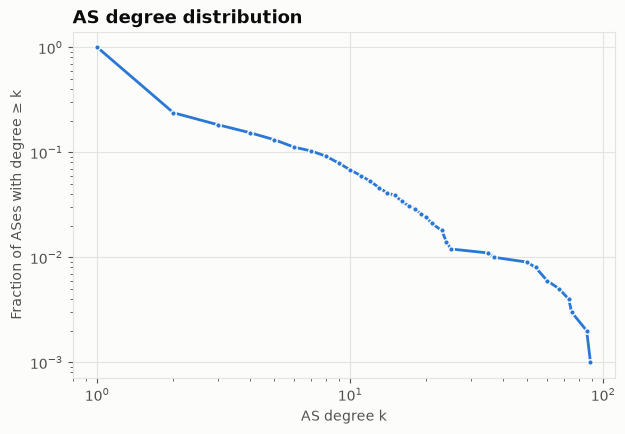

Median degree 1, mean 3.0
Largest hubs: as_9 (M, 89), as_0 (T, 86), as_5 (M, 75), as_1 (T, 73), as_4 (T, 67)


In [4]:
degrees = np.array(list(degree.values()))
k = np.unique(degrees)
ccdf = np.array([(degrees >= x).mean() for x in k])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k, ccdf, color="#2a78d6", linewidth=2, marker="o", markersize=4,
        markeredgecolor=SURFACE, markeredgewidth=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("AS degree k")
ax.set_ylabel("Fraction of ASes with degree ≥ k")
ax.set_title("AS degree distribution", loc="left")
plt.show()

top = sorted(degree.items(), key=lambda item: -item[1])[:5]
print(f"Median degree {np.median(degrees):.0f}, mean {degrees.mean():.1f}")
print("Largest hubs:", ", ".join(f"{n} ({net.nodes[n]['as_type']}, {d})" for n, d in top))

## 4. Simulate traffic on the network

We place one service on every host and create random flows between them. Each step
moves every packet by one hop, so `step_duration_s` should be at least as long as the
slowest hop: the Tier-1 links are 2000 km long by default, about 10 ms of propagation,
hence a step of 10 ms.

In [5]:
app = NetworkApplication("InternetApp")
mapping = {}
for host in net.hosts:
    service = f"svc_{host}"
    app.add_node(service, cpu=1, ram=1)
    mapping[service] = host

flow_rng = random.Random(SEED)
while app.number_of_edges() < 60:
    src, dst = flow_rng.sample(net.hosts, 2)
    if not app.has_edge(f"svc_{src}", f"svc_{dst}"):
        app.add_edge(f"svc_{src}", f"svc_{dst}", packet_size_bytes=1500, avg_packets_per_step=4.0)

sim_config = SimulationConfig(
    seed=SEED,
    max_steps=60,
    path="./results_internet_as",
    events=[PacketGenerationEvent(), RoutingEvent(step_duration_s=0.01), RoutingMetric()],
    include_default_metrics=False,
    report_format="json",
    report_backend="pandas",
    remote=False,
)
sim = Simulation(net, simulation_config=sim_config)
sim.register(app, placement_strategy=StaticStrategy(mapping))
sim.start()
sim.wait()

print(f"{app.number_of_edges()} flows simulated for {sim_config.max_steps} steps")
print(f"Dropped packets: {net.dropped_packets}")

18:57:05.353 | INFO | InternetApp - Added flow svc_host_759_0->svc_host_219_0, 4.0 pkt/step (avg), size 1500B
18:57:05.354 | INFO | InternetApp - Added flow svc_host_167_1->svc_host_864_0, 4.0 pkt/step (avg), size 1500B
18:57:05.354 | INFO | InternetApp - Added flow svc_host_386_0->svc_host_355_0, 4.0 pkt/step (avg), size 1500B
18:57:05.355 | INFO | InternetApp - Added flow svc_host_333_0->svc_host_247_0, 4.0 pkt/step (avg), size 1500B
18:57:05.355 | INFO | InternetApp - Added flow svc_host_859_0->svc_host_209_0, 4.0 pkt/step (avg), size 1500B
18:57:05.355 | INFO | InternetApp - Added flow svc_host_797_0->svc_host_863_0, 4.0 pkt/step (avg), size 1500B
18:57:05.355 | INFO | InternetApp - Added flow svc_host_663_0->svc_host_199_1, 4.0 pkt/step (avg), size 1500B
18:57:05.356 | INFO | InternetApp - Added flow svc_host_709_0->svc_host_537_0, 4.0 pkt/step (avg), size 1500B
18:57:05.356 | INFO | InternetApp - Added flow svc_host_171_0->svc_host_170_0, 4.0 pkt/step (avg), size 1500B
18:57:05.3

18:57:20.613 | INFO | internet_as_net - as_721 order: [13903 (host_721_0), 13904 (host_721_0), 13905 (host_721_0)]
18:57:20.614 | INFO | internet_as_net - as_728 order: [12738 (as_34), 12739 (as_34), 12740 (as_34), 12741 (as_34), 12742 (as_34), 12743 (as_34), 12744 (as_34)]
18:57:20.614 | INFO | internet_as_net - as_738 order: [13907 (host_738_0), 13908 (host_738_0), 13909 (host_738_0), 13910 (host_738_0), 13911 (host_738_0)]
18:57:20.615 | INFO | internet_as_net - as_748 order: [13200 (as_1), 13201 (as_1), 13202 (as_1), 13203 (as_1)]
18:57:20.615 | INFO | internet_as_net - as_755 order: [13912 (host_755_0), 13913 (host_755_0), 13914 (host_755_0), 13915 (host_755_0), 13916 (host_755_0), 13917 (host_755_0), 13918 (host_755_0), 13919 (host_755_0)]
18:57:20.616 | INFO | internet_as_net - as_759 order: [13920 (host_759_0), 13921 (host_759_0)]
18:57:20.616 | INFO | internet_as_net - as_768 order: [12938 (as_2), 12939 (as_2), 12940 (as_2)]


Read the per-hop telemetry written by `RoutingMetric`.

In [6]:
frames = []
with open(os.path.join(sim_config.path, "json", "application.jsonl")) as file:
    for line in file:
        record = json.loads(line)
        if record.get("callback_name") != "traffic_routing":
            continue
        columns = {name: values for _, name, values in (m for m in record["data"] if len(m) == 3)}
        if columns:
            frames.append(pd.DataFrame(columns))

hops = pd.concat(frames, ignore_index=True)
hops["link_class"] = [net.edges[tuple(hop.split("->"))]["link_class"] for hop in hops["hop"]]
components = ["processing_ms", "queue_ms", "transmission_ms", "propagation_ms"]

print(f"{len(hops)} hops recorded, {hops['packet_id'].nunique()} distinct packets")
print(hops.head().to_string())

18:57:20.616 | INFO | internet_as_net - as_770 order: [12947 (as_40), 12948 (as_40), 12949 (as_40), 12950 (as_40), 12951 (as_40), 12952 (as_40)]
18:57:20.616 | INFO | internet_as_net - as_782 order: [13922 (host_782_0), 13923 (host_782_0), 13924 (host_782_0), 13925 (host_782_0)]
18:57:20.618 | INFO | internet_as_net - as_791 order: [12766 (as_5), 12767 (as_5), 12768 (as_5), 12769 (as_5), 12770 (as_5), 12771 (as_5), 12772 (as_5)]
18:57:20.618 | INFO | internet_as_net - as_797 order: [13926 (host_797_0), 13927 (host_797_0)]
18:57:20.618 | INFO | internet_as_net - as_804 order: [13928 (host_804_0), 13929 (host_804_0), 13930 (host_804_0)]
18:57:20.618 | INFO | internet_as_net - as_806 order: [12780 (as_32), 12781 (as_32), 12782 (as_32), 12783 (as_32), 12784 (as_32), 12785 (as_32), 12786 (as_32)]
18:57:20.620 | INFO | internet_as_net - as_809 order: [13931 (host_809_0), 13932 (host_809_0)]
18:57:20.620 | INFO | internet_as_net - as_819 order: [13255 (as_92), 13256 (as_92), 13257 (as_92), 13

## 5. Where the delay comes from

Mean delay of a hop on each link class, split into its four components. With the
default lengths, propagation dominates the AS links; on the host links, queuing and
transmission dominate, because the packets of a flow generated in the same step leave
the host together.

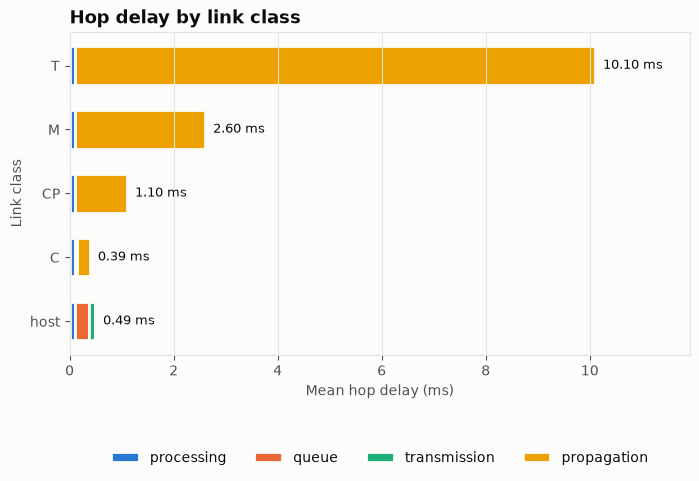

            processing_ms  queue_ms  transmission_ms  propagation_ms
link_class                                                          
T                     0.1     0.000            0.000          10.000
M                     0.1     0.003            0.001           2.500
CP                    0.1     0.003            0.001           1.000
C                     0.1     0.027            0.012           0.250
host                  0.1     0.264            0.120           0.005


In [7]:
by_class = hops[~hops["dropped"]].groupby("link_class")[components].mean().reindex(LINK_CLASSES)

COMPONENT_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
fig, ax = plt.subplots(figsize=(8, 4.2))
left = np.zeros(len(by_class))
for name, color in zip(components, COMPONENT_COLORS):
    ax.barh(by_class.index, by_class[name], left=left, height=0.6, color=color,
            edgecolor=SURFACE, linewidth=2, label=name.removesuffix("_ms"))
    left += by_class[name].to_numpy()
for y, total in enumerate(left):
    ax.text(total, y, f"  {total:.2f} ms", va="center", color=TEXT, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, left.max() * 1.18)
ax.set_xlabel("Mean hop delay (ms)")
ax.set_ylabel("Link class")
ax.set_title("Hop delay by link class", loc="left")
ax.grid(axis="y", visible=False)
ax.legend(ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.38))
plt.show()

print(by_class.round(3).to_string())

## 6. Traffic on the AS graph

Finally, we color each AS link by the number of packets it carried during the
simulation (both directions), on the same layout as before. Traffic concentrates on
the links of the hubs at the center.

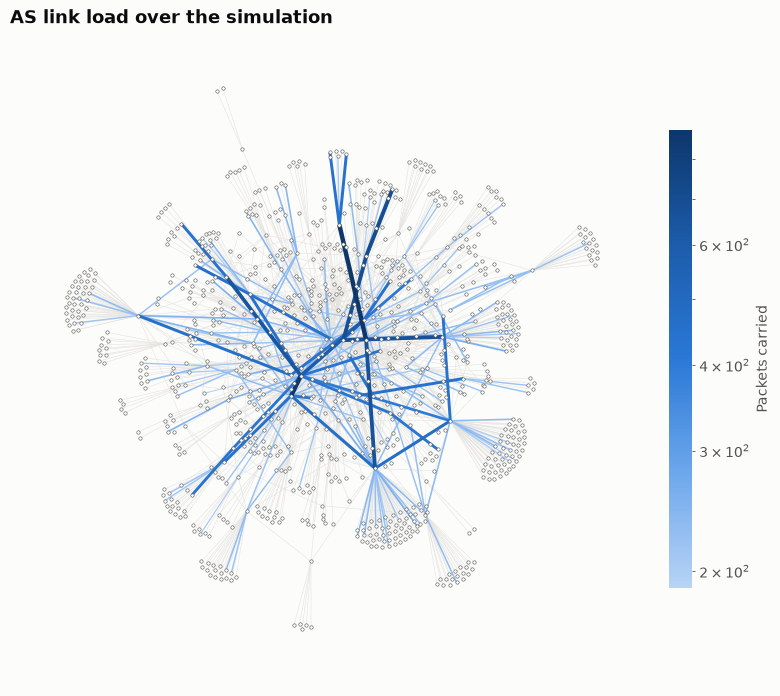

Busiest AS links:
   as_124 ( M) <-> as_18   ( M)     883 packets, peer
     as_3 ( T) <-> as_4    ( T)     853 packets, peer
    as_25 ( M) <-> as_389  ( C)     703 packets, transit
    as_25 ( M) <-> as_8    ( M)     686 packets, peer
    as_15 ( M) <-> as_8    ( M)     673 packets, peer


In [8]:
load = hops.groupby("hop").size()
undirected = {}
for hop, count in load.items():
    u, v = hop.split("->")
    if u in net.routers and v in net.routers:
        key = tuple(sorted((u, v)))
        undirected[key] = undirected.get(key, 0) + count

ramp = LinearSegmentedColormap.from_list(
    "blue_ramp", ["#b7d3f6", "#6da7ec", "#2a78d6", "#1c5cab", "#0d366b"]
)
norm = LogNorm(vmin=min(undirected.values()), vmax=max(undirected.values()))

fig, ax = plt.subplots(figsize=(10, 8.5))
idle = [(u, v) for u, v in as_graph.edges() if tuple(sorted((u, v))) not in undirected]
nx.draw_networkx_edges(as_graph, layout, edgelist=idle, ax=ax, width=0.4, edge_color=GRID)
busy = sorted(undirected, key=undirected.get)  # heaviest links drawn last
nx.draw_networkx_edges(
    as_graph, layout, edgelist=busy, ax=ax,
    width=[0.8 + 2.4 * norm(undirected[e]) for e in busy],
    edge_color=[ramp(norm(undirected[e])) for e in busy],
)
nx.draw_networkx_nodes(as_graph, layout, ax=ax, node_color=SURFACE, node_size=6,
                       edgecolors=TEXT_MUTED, linewidths=0.4)
colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=ramp), ax=ax, shrink=0.7, pad=0.02)
colorbar.set_label("Packets carried", color=TEXT_MUTED)
colorbar.outline.set_visible(False)
ax.set_title("AS link load over the simulation", loc="left")
ax.axis("off")
plt.show()

print("Busiest AS links:")
for (u, v), count in sorted(undirected.items(), key=lambda item: -item[1])[:5]:
    d = net.edges[u, v]
    print(f"  {u:>7} ({net.nodes[u]['as_type']:>2}) <-> {v:<7} ({net.nodes[v]['as_type']:>2})"
          f"  {count:6d} packets, {d['relationship']}")

## Notes

- Routing in `Network` follows minimum-cost paths (cost = 1 / bandwidth), not BGP
  policies. Real inter-domain routes are *valley-free*: an AS does not carry traffic
  between two of its providers or peers. With the default bandwidths, customer ASes
  are never used as transit, but a small fraction of paths can cross a content
  provider.
- Link lengths are constants per class, since the AS model has no geography. Change
  them with `length_km={...}` to explore different propagation scenarios.